In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [19]:
stock_raw=pd.read_csv('/content/NIFTY 50-9-12-2023-to-9-12-2024.csv')

In [20]:
stock_raw.head()

,Date,Open,High,Low,Close,Shares Traded,Turnover (₹ Cr)
0,11-DEC-2023,20965.30,21026.1,20923.70,20997.10,212921451.0,21150.17
1,12-DEC-2023,21018.55,21037.9,20867.15,20906.40,244867128.0,25404.64
2,13-DEC-2023,20929.75,20950.0,20769.50,20926.35,260269318.0,25918.44
3,14-DEC-2023,21110.40,21210.9,21074.45,21182.70,334410589.0,32593.42
4,15-DEC-2023,21287.45,21492.3,21235.30,21456.65,508761756.0,50114.46


In [21]:
stock_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 247 entries, 0 to 246
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Date             247 non-null    object 
 1   Open             247 non-null    float64
 2   High             247 non-null    float64
 3   Low              247 non-null    float64
 4   Close            247 non-null    float64
 5   Shares Traded    246 non-null    float64
 6   Turnover (₹ Cr)  246 non-null    float64
dtypes: float64(6), object(1)
memory usage: 13.6+ KB


In [22]:
stock_raw['Date '] = pd.to_datetime(stock_raw['Date '], errors='coerce')

In [23]:
stock_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 247 entries, 0 to 246
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Date             247 non-null    datetime64[ns]
 1   Open             247 non-null    float64       
 2   High             247 non-null    float64       
 3   Low              247 non-null    float64       
 4   Close            247 non-null    float64       
 5   Shares Traded    246 non-null    float64       
 6   Turnover (₹ Cr)  246 non-null    float64       
dtypes: datetime64[ns](1), float64(6)
memory usage: 13.6 KB


In [24]:
stock_raw.set_index('Date ', inplace=True)

In [25]:
stock_raw

,Open,High,Low,Close,Shares Traded,Turnover (₹ Cr)
Date,,,,,,
2023-12-11,20965.30,21026.10,20923.70,20997.10,212921451.0,21150.17
2023-12-12,21018.55,21037.90,20867.15,20906.40,244867128.0,25404.64
2023-12-13,20929.75,20950.00,20769.50,20926.35,260269318.0,25918.44
2023-12-14,21110.40,21210.90,21074.45,21182.70,334410589.0,32593.42
2023-12-15,21287.45,21492.30,21235.30,21456.65,508761756.0,50114.46
...,...,...,...,...,...,...
2024-12-02,24140.85,24301.70,24008.65,24276.05,220384187.0,23162.75
2024-12-03,24367.50,24481.35,24280.00,24457.15,339470947.0,34228.30
2024-12-04,24488.75,24573.20,24366.30,24467.45,348003156.0,34639.78


In [26]:
stock=stock_raw['Close ']

In [27]:
stock.head()

,Close
Date,
2023-12-11,20997.10
2023-12-12,20906.40
2023-12-13,20926.35
2023-12-14,21182.70
2023-12-15,21456.65


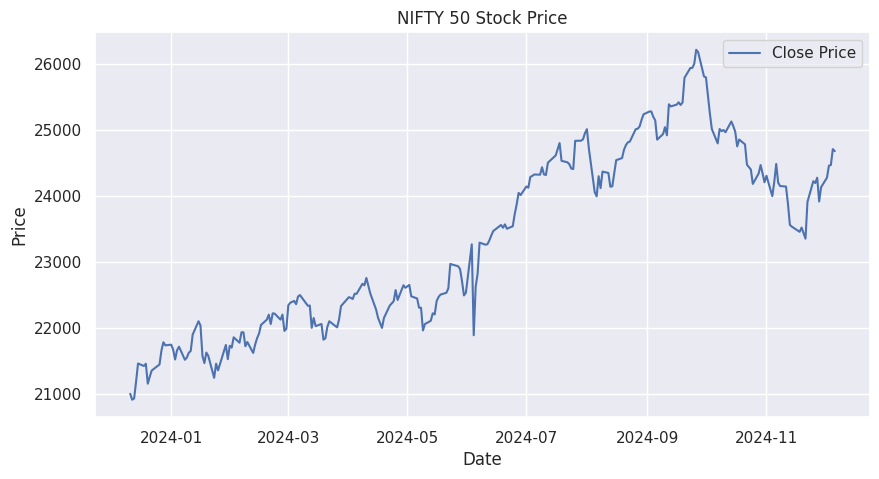

In [29]:
sns.set_theme()
plt.figure(figsize=(10,5))
plt.plot(stock)
plt.title('NIFTY 50 Stock Price')
plt.xlabel('Date')
plt.ylabel('Price')
plt.grid(True)
plt.legend(['Close Price'])
plt.show()

<Axes: xlabel='Close ', ylabel='Density'>

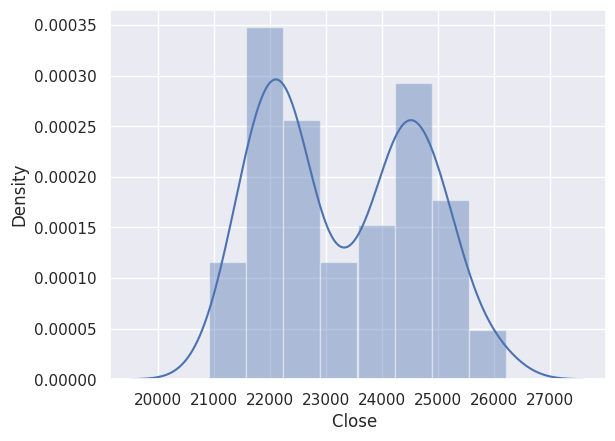

In [30]:
sns.distplot(stock)

In [31]:
from statsmodels.tsa.seasonal import seasonal_decompose

In [32]:
stat=seasonal_decompose(stock,model='additive',period=30)

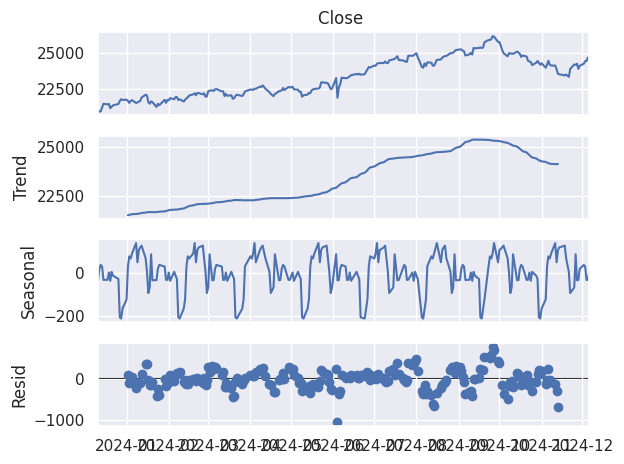

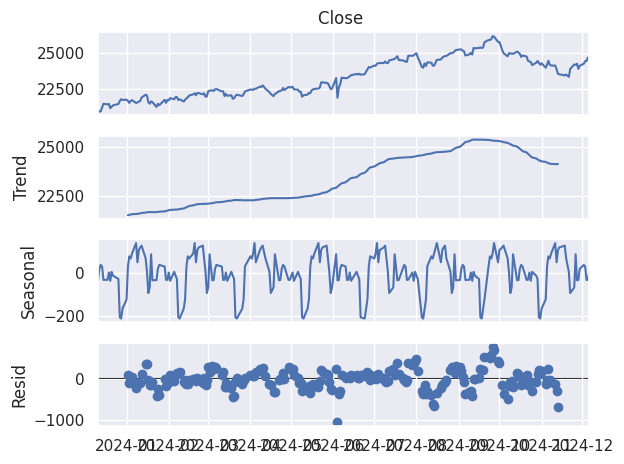

In [36]:

stat.plot()

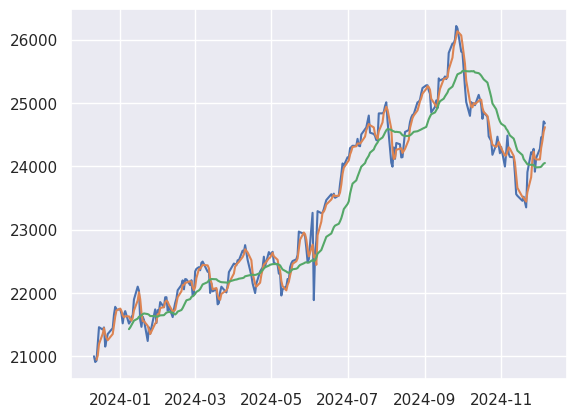

In [38]:
plt.plot(stock)
plt.plot(stock.rolling(3).mean())
plt.plot(stock.rolling(20).mean())


In [39]:
from statsmodels.tsa.stattools import adfuller

In [40]:
adf=adfuller(stock)

In [41]:
adf

(-1.5316186734114732,
 0.5178161102057567,
 1,
 245,
 {'1%': -3.4573260719088132,
  '5%': -2.873410402808354,
  '10%': -2.573095980841316},
 3104.716731668846)

In [42]:
pd.Series(adf[0:4],index=['Test Statistic','p-value','Lags Used','Number of Observations Used'])

,0
Test Statistic,-1.531619
p-value,0.517816
Lags Used,1.000000
Number of Observations Used,245.000000


In [43]:
stock=stock.diff(2)

In [47]:
stock=stock.dropna()

In [48]:
adf=adfuller(stock)

In [49]:
adf

(-5.3683586267418555,
 3.945987953656192e-06,
 8,
 236,
 {'1%': -3.4583663275730476,
  '5%': -2.8738660999177132,
  '10%': -2.5733390785693766},
 3106.6999406225596)

In [50]:
pd.Series(adf[0:4],index=['Test Statistic','p-value','Lags Used','Number of Observations Used'])

,0
Test Statistic,-5.368359
p-value,0.000004
Lags Used,8.000000
Number of Observations Used,236.000000


In [51]:
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf

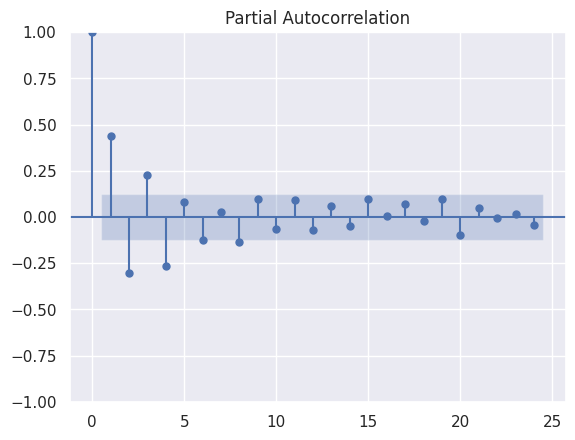

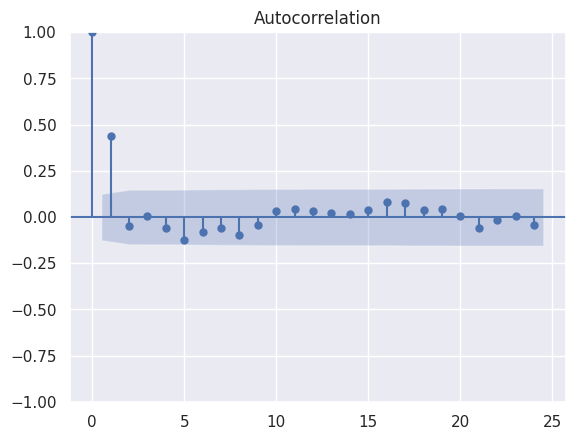

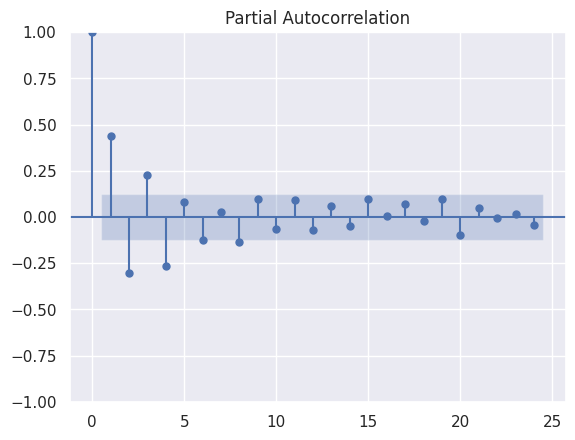

In [52]:
plot_acf(stock)
plot_pacf(stock)

In [65]:
import statsmodels.api as sm
import statsmodels.tsa.arima_model as ARIMA

In [54]:
history=[x for x in stock]

In [56]:
train=stock[0:-60]

In [57]:
test=stock[61:]

In [62]:
history=[x for x in train]

In [67]:
from statsmodels.tsa.arima.model import ARIMA # Import the ARIMA class

# ... your existing code ...

history = [x for x in train]
model = ARIMA(history, order=(1, 1, 1)) # Call the ARIMA class

In [74]:
result=model.fit()


In [76]:
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  185
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -1266.425
Date:                Mon, 09 Dec 2024   AIC                           2538.849
Time:                        07:12:54   BIC                           2548.494
Sample:                             0   HQIC                          2542.758
                                - 185                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3829      0.048      7.924      0.000       0.288       0.478
ma.L1         -0.9999      4.828     -0.207      0.836     -10.463       8.463
sigma2      5.439e+04   2.63e+05      0.207      0.836   -4.62e+05    5.71e+05
===================================================================================
Ljung-Box (L1) (Q):                   3.18   Jarque-Bera (JB):               219.09
Prob(Q):                              0.07   Prob(JB):                         0.00
Heteroskedasticity (H):               1.12   Skew:                             0.14
Prob(H) (two-sided):                  0.65   Kurtosis:                         8.34
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [85]:
result.forecast()[0]

99.3468254297807

In [86]:
from sklearn.metrics import mean_squared_error

In [88]:
mean_squared_error([test[0]],result.forecast())

57959.03395451625

In [89]:
def train_arima_model(X, y, arima_order):
    # prepare training dataset
    # make predictions list
    history = [x for x in X]
    predictions = list()
    for t in range(len(y)):
        model = ARIMA(history, order=arima_order)
        model_fit = model.fit()
        yhat = model_fit.forecast()[0]
        predictions.append(yhat)
        history.append(y[t])
    # calculate out of sample error
    rmse = np.sqrt(mean_squared_error(y, predictions))
    return rmse

In [91]:
import warnings
warnings.filterwarnings('ignore')
p_values = range(0, 3)
d_values = range(0, 3)
q_values = range(0, 3)

In [94]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
import numpy as np

def evaluate_models(dataset, test, p_values, d_values, q_values):
    """
    Evaluate combinations of p, d, and q values for ARIMA models
    and select the best configuration based on RMSE.
    """
    dataset = dataset.astype('float32')
    best_score, best_cfg = float("inf"), None

    for p in p_values:
        for d in d_values:
            for q in q_values:
                order = (p, d, q)
                try:
                    rmse = train_arima_model(dataset, test, order)
                    if rmse < best_score:
                        best_score, best_cfg = rmse, order
                    print(f'ARIMA{order} RMSE: {rmse:.3f}')
                except Exception as e:
                    print(f'Error with ARIMA{order}: {e}')

    print(f"Best ARIMA{best_cfg} RMSE: {best_score:.3f}")
    return best_cfg, best_score

In [95]:
evaluate_models(train,test,p_values,d_values,q_values)

ARIMA(0, 0, 0) RMSE: 280.555
ARIMA(0, 0, 1) RMSE: 224.512
ARIMA(0, 0, 2) RMSE: 221.405
ARIMA(0, 1, 0) RMSE: 294.616
ARIMA(0, 1, 1) RMSE: 281.479
ARIMA(0, 1, 2) RMSE: 224.470
ARIMA(0, 2, 0) RMSE: 436.212
ARIMA(0, 2, 1) RMSE: 295.168
ARIMA(0, 2, 2) RMSE: 283.937
ARIMA(1, 0, 0) RMSE: 252.857
ARIMA(1, 0, 1) RMSE: 220.719
ARIMA(1, 0, 2) RMSE: 226.017
ARIMA(1, 1, 0) RMSE: 294.655
ARIMA(1, 1, 1) RMSE: 252.782
ARIMA(1, 1, 2) RMSE: 220.714
ARIMA(1, 2, 0) RMSE: 416.444
ARIMA(1, 2, 1) RMSE: 295.225
ARIMA(1, 2, 2) RMSE: 272.747
ARIMA(2, 0, 0) RMSE: 245.834
ARIMA(2, 0, 1) RMSE: 221.737
ARIMA(2, 0, 2) RMSE: 222.871
ARIMA(2, 1, 0) RMSE: 258.870
ARIMA(2, 1, 1) RMSE: 248.518
ARIMA(2, 1, 2) RMSE: 221.827
ARIMA(2, 2, 0) RMSE: 323.576
ARIMA(2, 2, 1) RMSE: 259.366
ARIMA(2, 2, 2) RMSE: 263.195
Best ARIMA(1, 1, 2) RMSE: 220.714


((1, 1, 2), 220.71393925086642)

In [97]:
history=[x for x in train]
pred=[]
for i in range(len(test)):
  model=ARIMA(history,order=(1,1,2))
  model_fit=model.fit()
  yhat=model_fit.forecast()[0]
  pred.append(yhat)
  history.append(test[i])

In [103]:
test_list=[x for x in test]

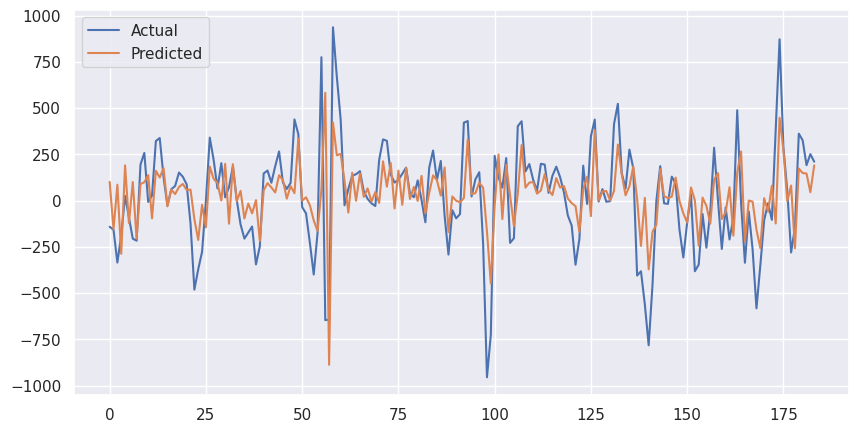

In [104]:
plt.figure(figsize=(10,5))
plt.plot(test_list,label='Actual')
plt.plot(pred,label='Predicted')
plt.legend()
plt.show()